<div style="padding: 20px 0; text-align: center; font-weight: bold; font-size: 170%; background-color: #1d4055; color: #ffffff;"> Εργαστήριο 06. Γραμμική Άλγεβρα </div>

Χρησιμοποιήστε την εντολή matrix() για να δημιουργήσετε τον παρακάτω πίνακα.

$$
M = \left(\begin{array}{rrrr}
10 & 4 & 1 & 1 \\
4 & 6 & 5 & 1 \\
1 & 5 & 6 & 4 \\
1 & 1 & 4 & 10
\end{array}\right)
$$

Έπειτα, χρησιμοποιώντας μεθόδους του πίνακα υπολογίστε:

- την ορίζουσα του πίνακα.

- Το ίχνος του

- Τις ιδιοτιμές του.

In [3]:
# Δημιουργία του πίνακα
M = matrix([[10, 4, 1, 1], 
            [4, 6, 5, 1], 
            [1, 5, 6, 4], 
            [1, 1, 4, 10]])

# 1. Ορίζουσα
determinant = M.determinant()
# 2. Ίχνος
tr = M.trace()
# 3. Ιδιοτιμές
eigenvalues = M.eigenvalues()

determinant, tr, eigenvalues

(0, 32, [16, 10, 6, 0])

# Γωνίες διανυσμάτων

Έστω τα διανύσματα: A = (2, 1), B = (1, 3), C = (3, 2). Ορίστε τα και σχεδιάστε τα με βέλη. Βρείτε όλες τις γωνίες μεταξύ των διανυσμάτων. Μπορείτε για τον λόγο αυτό να δημιουργήσετε συνάρτηση Python.

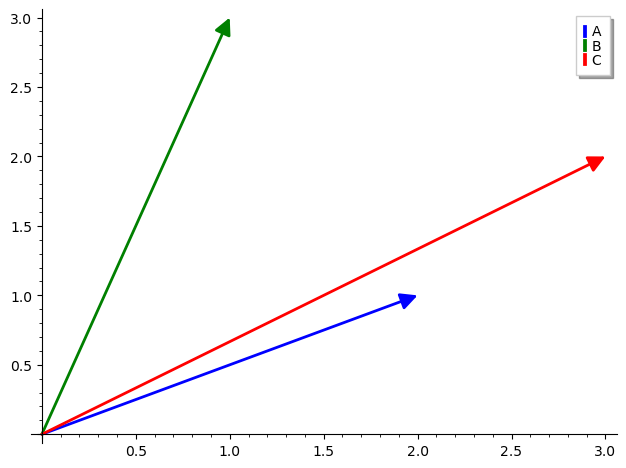

(0.785398163397448, 0.124354994546762, 0.661043168850687)

In [4]:
# Ορισμός διανυσμάτων
A = vector([2, 1])
B = vector([1, 3])
C = vector([3, 2])

# Υπολογισμός γωνιών
def getAngle(u, v):
    cos_theta = (u.dot_product(v)) / (u.norm() * v.norm())
    theta = arccos(cos_theta)
    return theta

theta_AB = getAngle(A, B)
theta_AC = getAngle(A, C)
theta_BC = getAngle(B, C)

g = Graphics()
g += plot(vector([0, 0]), color="white")  # Κενό plot για προσθήκη διανυσμάτων
g += arrow((0, 0), (A[0], A[1]), color="blue", legend_label="A")
g += arrow((0, 0), (B[0], B[1]), color="green", legend_label="B")
g += arrow((0, 0), (C[0], C[1]), color="red", legend_label="C")
g.show()
N(theta_AB),N(theta_AC),N(theta_BC)

# Πρόσθεση διανυσμάτων

Έστω τα διανύσματα u=(2,3), v = (4,2). Προσθέστε τα και δείξτε σε ένα γράφημα το άθροισμα και τα αρχικά διανύσματα σαν βέλη διάφορων χρωμάτων. Μπορείτε να θέσετε και κάποιο πλέγμα για καλύτερη απεικόνιση.

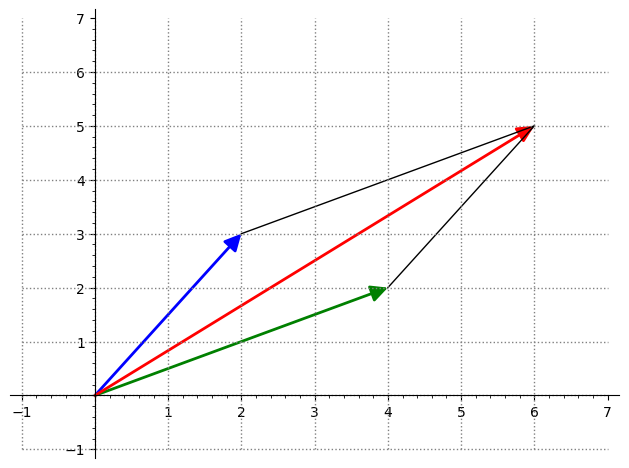

In [5]:
u = vector([2, 3])
v = vector([4, 2])
sumvector = u + v
g = Graphics()
g += arrow((0,0), u, color='blue')
g += arrow((0,0), v, color='green')
g += arrow((0,0), sumvector, color='red')
g += line([u,sumvector], color='black')
g += line([v,sumvector], color='black')
for i in range(-1,7):
    g += line([(-1,i),(7,i)], color='gray', linestyle='dotted')
for i in range(-1,7):
    g += line([(i,-1),(i,7)], color='gray', linestyle='dotted')
g.show()

# Γραμμικοί μετασχηματισμοί

Υλοποιήστε συνάρτηση Python που δέχεται ένα διάνυσμα και έναν πίνακα περιστροφής, υπολογίζει το νέο διάνυσμα μετά την περιστροφή, το σχεδιάζει μαζί με το αρχικό καθώς και ένα πλέγμα, και επιστρέφει το νέο διάνυσμα. Καλέστε κατάλληλα την συνάρτησή σας για διάφορες περιπτώσεις όπως περιστροφή, συστολή.

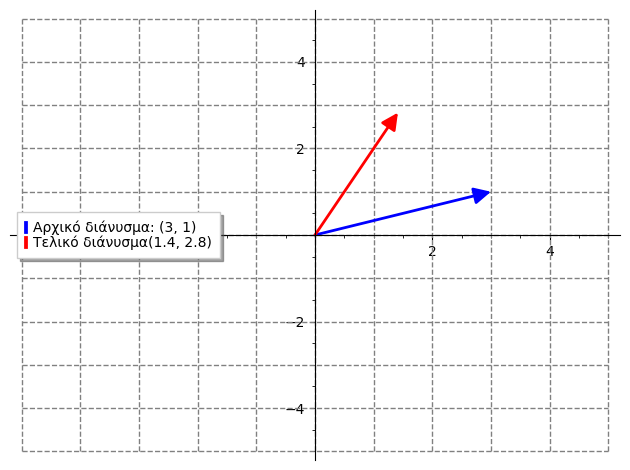

Νέο διάνυσμα μετά την περιστροφή: (sqrt(2), 2*sqrt(2))


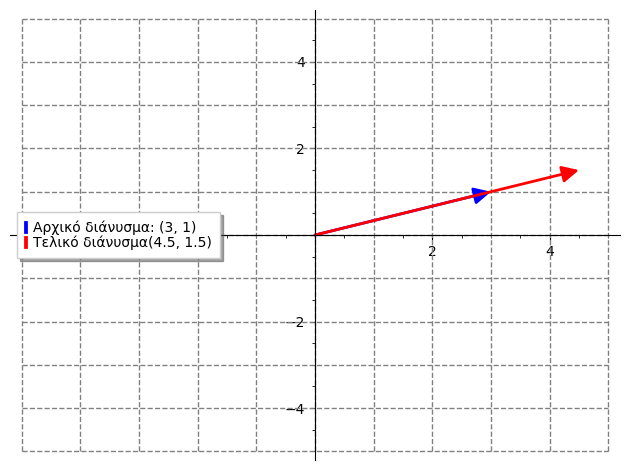

Νέο διάνυσμα μετά την αλλαγή μεγέθους: (4.50000000000000, 1.50000000000000)


In [6]:
def changeplot(vector, changematrix, gridrange=5):
    nv = changematrix * vector
    g = Graphics()
    for x in range(-gridrange, gridrange + 1):
        g += line([(x, -gridrange), (x, gridrange)], color="gray", linestyle="--")
    for y in range(-gridrange, gridrange + 1):
        g += line([(-gridrange, y), (gridrange, y)], color="gray", linestyle="--")
    
    g += arrow((0, 0), v, color='blue', thickness=2, legend_label='Αρχικό διάνυσμα: '+str(v))
    g += arrow((0, 0), nv, color="red", thickness=2, legend_label='Τελικό διάνυσμα'+str(N(nv,digits=2)))
    
    g.show(axes=True)
    return nv

v = vector([3, 1])
theta = pi / 4
changematrix = matrix([[cos(theta), -sin(theta)], [sin(theta), cos(theta)]])
new_v = changeplot(v, changematrix)
print("Νέο διάνυσμα μετά την περιστροφή:", new_v)
k = 1.5
changematrix = matrix([[k, 0], [0, k]])
new_v = changeplot(v, changematrix)
print("Νέο διάνυσμα μετά την αλλαγή μεγέθους:", new_v)

# Γραμμικοί μετασχηματισμοί, παραμόρφωση σχήματος

Δημιουργήστε ένα σχήμα, για παράδειγμα ένα απλό σπιτάκι με μία λίστα γραμμών και στη συνέχεια παραμορφώστε το με κατάλληλο μετασχηματισμό. Δίνεται μία λίστα με ένα πολύ απλό σχήμα σπιτιού

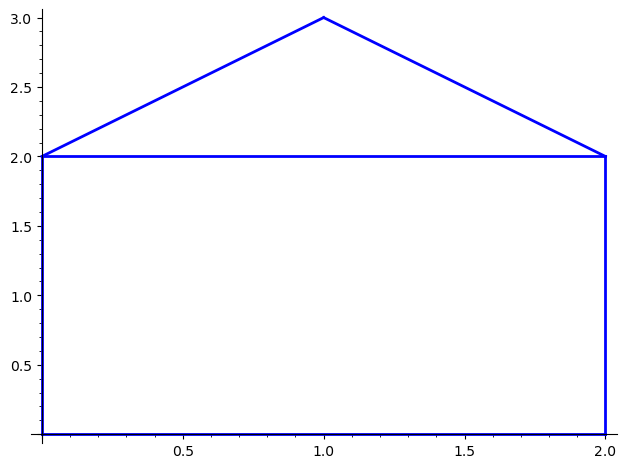

In [7]:
house = [
    ((0, 0), (0, 2)),
    ((0, 2), (2, 2)),
    ((2, 2), (2, 0)),
    ((2, 0), (0, 0)),
    ((0, 2), (1, 3)),
    ((2, 2), (1, 3))
]
g = Graphics()
for edge in house:
    start, end = edge
    g += line([start, end], color="blue", thickness=2)
g.show(axes=True)

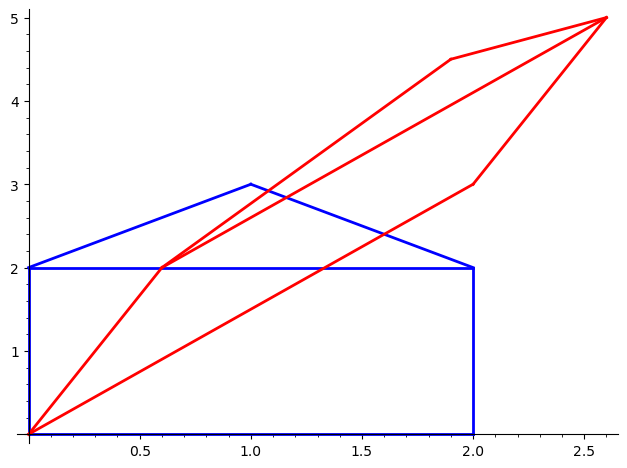

In [8]:
skewmatrix = matrix([[1, 0.3], [1.5, 1]])

skewhouse = []
for edge in house: 
    start, end = edge
    skewstart = skewmatrix * vector(start)
    skewend = skewmatrix * vector(end)
    skewhouse.append((skewstart, skewend))


g = Graphics()
# Αρχικό σπίτι
for edge in house:
    start, end = edge
    g += line([start, end], color="blue", thickness=2)
# Παραμορφωμένο σπίτι
for edge in skewhouse:
    start, end = edge
    g += line([start, end], color="red", thickness=2)
g.show(axes=True)

# Επαυξημένη μήτρα

Έστω το σύστημα γραμμικών εξισώσεων:
$$
\begin{aligned}
    2x_1 + 3x_2 - x_3 &= 4 \\
    -x_1 + 7x_2 + 5x_3 &= -2 \\
    4x_1 - 2x_2 + 6x_3 &= 7
\end{aligned}
$$
Δημιουργήστε την μήτρα συντελεστών και σταθερών και στην συνέχεια την επαυξημένη μήτρα.

In [9]:
 # Ορισμός του συστήματος
A = Matrix(QQ, [
    [2, 3, -1],
    [-1, 7, 5],
    [4, -2, 6]
])
b = vector(QQ, [4, -2, 7])

augmented_matrix = A.augment(b, subdivide=True)

# Σύστημα γραμμικών εξισώσεων

Χρησιμοποιήστε την `solve` αλλά και την παραγοντοποίηση LU για να λύσετε το επόμενο σύστημα.
$$
\begin{aligned}
    x_1 + 2x_2 &= 5 \\
    3x_1 + 4x_2 &= 6
\end{aligned}
$$

Προσοχή: Όταν υπάρχει αναδιάταξη στον πίνακα P θα πρέπει πρώτα $Ly=Pb$ και στη συνέχεια: $Ux=y$

Δείξτε και τους ενδιάμεσους πίνακες L και U.

In [10]:
# 1
A = matrix([[1, 2], [3, 4]])
b = vector([5, 6])

x = A.solve_right(b)
show(x)

(-4, 9/2)

In [11]:
# 2
P, L, U = A.LU()
print(A==P*L*U)
show(P)
show(identity_matrix(2))
print('L:')
show(L)
print('U:')
show(U)
y = L.solve_right(P*b)
x = U.solve_right(y)
show(x)
show(A.solve_right(b))

True


[0 1]
[1 0]

[1 0]
[0 1]

L:


[  1   0]
[1/3   1]

U:


[  3   4]
[  0 2/3]

(-4, 9/2)

(-4, 9/2)

# Μέθοδοι Jacobi, Gauss-Seidel

Έστω το σύστημα:
$$
\begin{aligned}
    4x_1 + x_2 &= 9 \\
    x_1 + 3x_2 &= 8
\end{aligned}
$$
Η εφαρμογή των μεθόδων Jacobi και Gauss-Seidel των σημειώσεων που ακολουθούν, λύνουν το σύστημα για συγκεκριμένο αριθμό επαναλήψεων. Προσαρμόστε την μέθοδο ώστε το κριτήριο σύγκλισης να είναι αν η μέγιστη απόλυτη διαφορά μεταξύ των στοιχείων του xnew και του x είναι μικρότερη από το όριο ανοχής tolerance. Μπορείτε να θέσετε και μέγιστο αριθμό επαναλήψεων για να αποφευχθεί το ενδεχόμενο ο αλγόριθμος να "κολλήσει".

Τί έχετε να παρατηρήσετε για τον αριθμό των επαναλήψεων που απαιτούνται στις δύο μεθόδους;

In [4]:
# Σύστημα
A = Matrix(RR, [[4, 1], [1, 3]])
b = vector(RR,[9, 8])

In [13]:
# Jacobi
x = vector(RR,[0, 0]) # Αρχική προσέγγιση
iterations = 10
for k in range(iterations):
    x_new = vector(RR,[0, 0])
    x_new[0] = (b[0] - A[0, 1]*x[1]) / A[0, 0]
    x_new[1] = (b[1] - A[1, 0]*x[0]) / A[1, 1]
    x = x_new
    print('Επανάληψη:',k+1,': x  =',x)
show(A.solve_right(b)) # Επαλήθευση

Επανάληψη: 1 : x  = (2.25000000000000, 2.66666666666667)
Επανάληψη: 2 : x  = (1.58333333333333, 1.91666666666667)
Επανάληψη: 3 : x  = (1.77083333333333, 2.13888888888889)
Επανάληψη: 4 : x  = (1.71527777777778, 2.07638888888889)
Επανάληψη: 5 : x  = (1.73090277777778, 2.09490740740741)
Επανάληψη: 6 : x  = (1.72627314814815, 2.08969907407407)
Επανάληψη: 7 : x  = (1.72757523148148, 2.09124228395062)
Επανάληψη: 8 : x  = (1.72718942901235, 2.09080825617284)
Επανάληψη: 9 : x  = (1.72729793595679, 2.09093685699588)
Επανάληψη: 10 : x  = (1.72726578575103, 2.09090068801440)


(1.72727272727273, 2.09090909090909)

In [14]:
# Gauss-Seidel
x = vector(RR,[0, 0]) # Αρχική προσέγγιση
iterations = 10
for k in range(iterations):
    x[0] = (b[0] - A[0, 1]*x[1]) / A[0, 0]
    x[1] = (b[1] - A[1, 0]*x[0]) / A[1, 1]
    print('Επανάληψη:',k+1,': x  =',x)

Επανάληψη: 1 : x  = (2.25000000000000, 1.91666666666667)
Επανάληψη: 2 : x  = (1.77083333333333, 2.07638888888889)
Επανάληψη: 3 : x  = (1.73090277777778, 2.08969907407407)
Επανάληψη: 4 : x  = (1.72757523148148, 2.09080825617284)
Επανάληψη: 5 : x  = (1.72729793595679, 2.09090068801440)
Επανάληψη: 6 : x  = (1.72727482799640, 2.09090839066787)
Επανάληψη: 7 : x  = (1.72727290233303, 2.09090903255566)
Επανάληψη: 8 : x  = (1.72727274186109, 2.09090908604630)
Επανάληψη: 9 : x  = (1.72727272848842, 2.09090909050386)
Επανάληψη: 10 : x  = (1.72727272737404, 2.09090909087532)


In [15]:
# Αρχική προσέγγιση
x = vector(RR, [0, 0])
# Όριο ανοχής για τη σύγκλιση
tolerance = 1e-3
# Μέγιστος αριθμός επαναλήψεων (για αποφυγή ατέρμονου βρόχου)
max_iterations = 100
# Επανάληψη μέχρι να συγκλίνει η λύση
for k in range(max_iterations):
    x_new = vector(RR, [0, 0])
    x_new[0] = (b[0] - A[0, 1] * x[1]) / A[0, 0]
    x_new[1] = (b[1] - A[1, 0] * x[0]) / A[1, 1]
    # Έλεγχος σύγκλισης
    if max(abs(x_new[i] - x[i]) for i in range(len(x))) < tolerance:
        print('Η λύση συγκλίνει στην επανάληψη:', k + 1)
        x = x_new
        break
    # Ενημέρωση του x για την επόμενη επανάληψη
    x = x_new
    print('Επανάληψη:', k + 1, ': x =', x)

# Εμφάνιση της τελικής λύσης
print('Τελική λύση:', x)

Επανάληψη: 1 : x = (2.25000000000000, 2.66666666666667)
Επανάληψη: 2 : x = (1.58333333333333, 1.91666666666667)
Επανάληψη: 3 : x = (1.77083333333333, 2.13888888888889)
Επανάληψη: 4 : x = (1.71527777777778, 2.07638888888889)
Επανάληψη: 5 : x = (1.73090277777778, 2.09490740740741)
Επανάληψη: 6 : x = (1.72627314814815, 2.08969907407407)
Επανάληψη: 7 : x = (1.72757523148148, 2.09124228395062)
Η λύση συγκλίνει στην επανάληψη: 8
Τελική λύση: (1.72718942901235, 2.09080825617284)


In [5]:
# Αρχική προσέγγιση
x = vector(RR, [0, 0])
# Όριο ανοχής για τη σύγκλιση
tolerance = 1e-3
# Μέγιστος αριθμός επαναλήψεων (για αποφυγή ατέρμονου βρόχου)
max_iterations = 100
# Επανάληψη μέχρι να συγκλίνει η λύση
for k in range(max_iterations):
    x_old = x[:]
    x[0] = (b[0] - A[0, 1] * x[1]) / A[0, 0]
    x[1] = (b[1] - A[1, 0] * x[0]) / A[1, 1]
    # Έλεγχος σύγκλισης
    if max(abs(x_old[i] - x[i]) for i in range(len(x))) < tolerance:
        print('Η λύση συγκλίνει στην επανάληψη:', k + 1)
        break
    print('Επανάληψη:', k + 1, ': x =', x)

# Εμφάνιση της τελικής λύσης
print('Τελική λύση:', x)

NameError: name 'x_new' is not defined